In [10]:
%%capture
!pip install -U diffusers
!pip install gradio_client
!pip install -U diffusers transformers accelerate

Now that `gradio_client` is installed, here's an example of how to use the `/preprocess` API endpoint. This will download an image, send it to the Gradio Space, and return the processed image.

In [11]:
from gradio_client import Client, file

client = Client("SIGMitch/InstantMesh")

# Provide a sample image URL. You can replace this with your own image file or URL.
input_image_url = '/content/photo_14_2024-08-20_11-55-42-removebg-preview.png'

# Call the /preprocess API endpoint
result = client.predict(
		input_image=file(input_image_url),
		do_remove_background=True,
		api_name="/preprocess"
)

print(f"Processed image output file path: {result}")


Loaded as API: https://sigmitch-instantmesh.hf.space ✔
Processed image output file path: /tmp/gradio/9366e6df136ffa675a03455b22819a81d3650309a307dd3451cd4c64392c473a/image.png


In [12]:
from google.colab import files

print("Please upload your image file:")
uploaded = files.upload()

# Get the path of the first uploaded file
if uploaded:
    uploaded_image_path = list(uploaded.keys())[0]
    print(f"Uploaded file path: {uploaded_image_path}")
else:
    uploaded_image_path = None
    print("No file uploaded.")

Please upload your image file:


Saving photo_11_2024-08-20_11-55-42.png to photo_11_2024-08-20_11-55-42.png
Uploaded file path: photo_11_2024-08-20_11-55-42.png


In [17]:
%%capture
!pip install gradio_client pillow requests google-colab

In [18]:
from google.colab import files
import os

print("Step 1: Upload your image file")
uploaded = files.upload()

if uploaded:
    input_path = list(uploaded.keys())[0]
    print(f"File uploaded: {input_path}")
else:
    raise ValueError("No file uploaded. Please upload an image to continue.")

Step 1: Upload your image file


Saving photo_14_2024-08-20_11-55-42.jpg to photo_14_2024-08-20_11-55-42.jpg
File uploaded: photo_14_2024-08-20_11-55-42.jpg


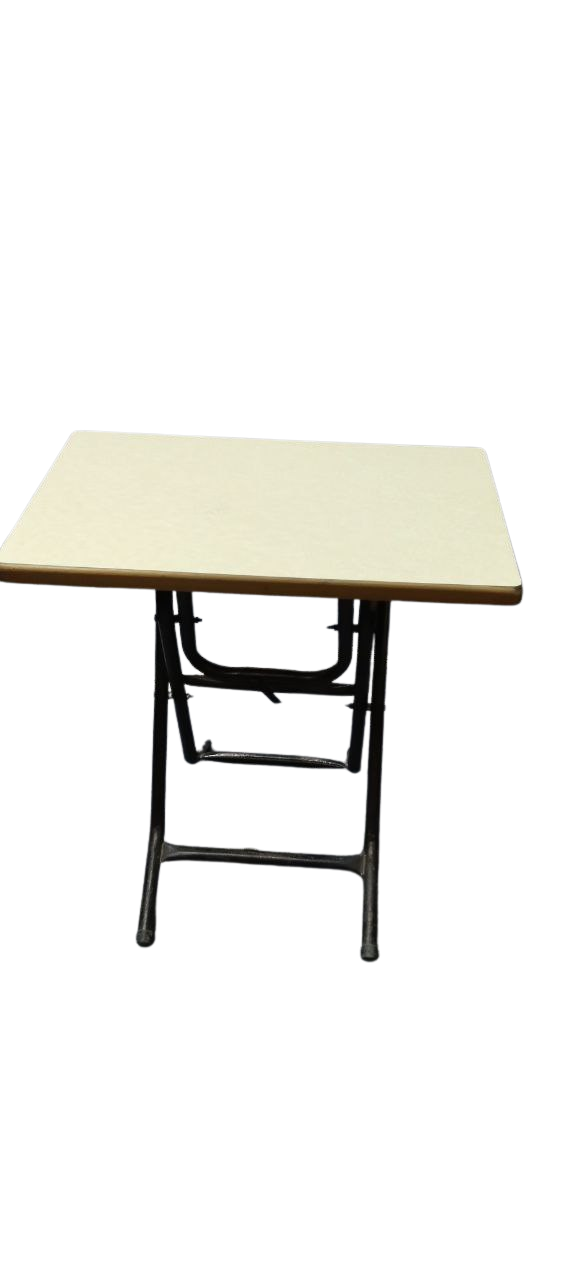

Background removed successfully.


In [19]:
import requests
from PIL import Image
from io import BytesIO

# @title Step 2: Remove Background (Remove.bg)
REMOVE_BG_API_KEY = "3SmQATau7ZtkEUozPLPexArH" # @param {type:"string"}

if not REMOVE_BG_API_KEY:
    print("No API key provided. Skipping background removal and using original image.")
    bg_removed_path = input_path
else:
    response = requests.post(
        'https://api.remove.bg/v1.0/removebg',
        files={'image_file': open(input_path, 'rb')},
        data={'size': 'auto'},
        headers={'X-Api-Key': REMOVE_BG_API_KEY},
    )
    if response.status_code == requests.codes.ok:
        bg_removed_path = "no_bg_image.png"
        with open(bg_removed_path, 'wb') as out:
            out.write(response.content)
        display(Image.open(bg_removed_path))
        print("Background removed successfully.")
    else:
        print("Error:", response.status_code, response.text)
        bg_removed_path = input_path

Loaded as API: https://sigmitch-instantmesh.hf.space ✔
Generating multi-views...
Multi-view image generated at: /tmp/gradio/4d93156cf27cfc11a3d51a6986bdb9f5331fd81794f3d98005628a145e730e1b/image.png


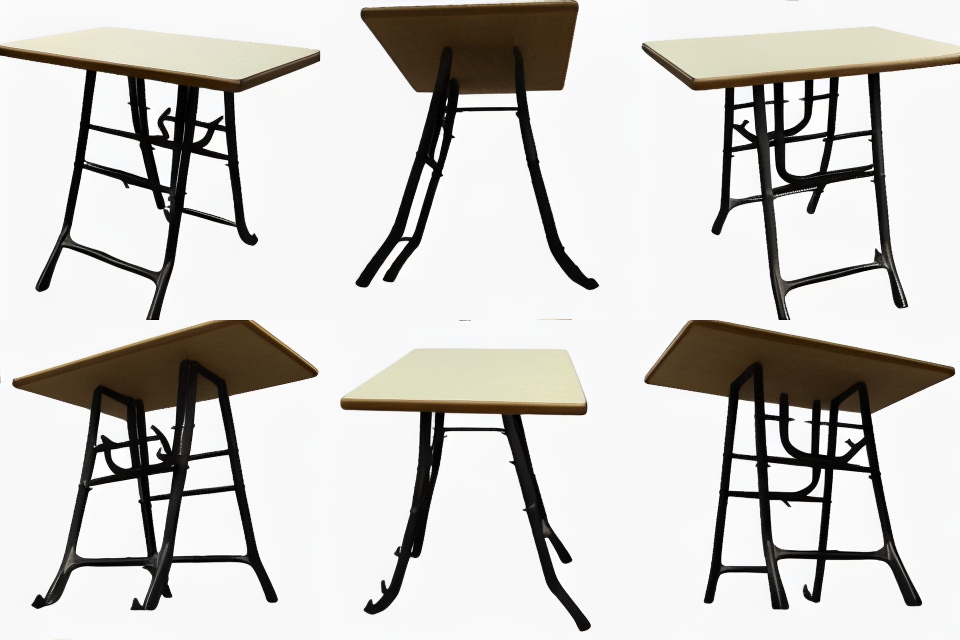

In [20]:
from gradio_client import Client, handle_file

# Step 3: Generate Multi-views
client = Client("SIGMitch/InstantMesh")

print("Generating multi-views...")
mvs_result = client.predict(
    input_image=handle_file(bg_removed_path),
    sample_steps=75,
    sample_seed=42,
    api_name="/generate_mvs"
)

print(f"Multi-view image generated at: {mvs_result}")
display(Image.open(mvs_result))

In [21]:
import shutil

# Step 4: Generate 3D Model
print("Generating 3D model (OBJ/GLB)...")
make3d_result = client.predict(
    api_name="/make3d"
)

# The result is usually a list containing paths to [obj_file, glb_file]
print("3D Model files generated:")
for file_path in make3d_result:
    filename = os.path.basename(file_path)
    shutil.copy(file_path, f"./{filename}")
    print(f"Saved: {filename}")

# Provide download links for the files
from google.colab import files as colab_files
for file_path in make3d_result:
    colab_files.download(os.path.basename(file_path))

Generating 3D model (OBJ/GLB)...
3D Model files generated:
Saved: tmp5l7m44et.obj
Saved: tmp5l7m44et.glb


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

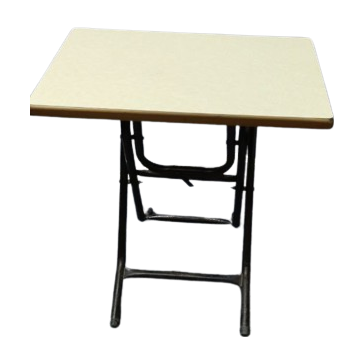

In [14]:
import requests
from PIL import Image
from io import BytesIO

# The 'result' variable contains a local file path, not a URL.
# Therefore, we should open the image directly using PIL.Image.open().
# response = requests.get(result) # This line caused the MissingSchema error
img = Image.open(result)
display(img)

Finally, let's call the `/make3d` API endpoint to generate the final 3D models (OBJ and GLB formats). This endpoint doesn't require any inputs.

In [23]:
from gradio_client import Client

# Inspect the API to find the correct video endpoint
client = Client("SIGMitch/InstantMesh")
client.view_api()

Loaded as API: https://sigmitch-instantmesh.hf.space ✔
Client.predict() Usage Info
---------------------------
Named API endpoints: 4

 - predict(input_image, api_name="/check_input_image") -> 
    Parameters:
     - [Image] input_image: filepath (required)  
    Returns:
     - None

 - predict(input_image, do_remove_background, api_name="/preprocess") -> processed_image
    Parameters:
     - [Image] input_image: filepath (required)  
     - [Checkbox] do_remove_background: bool (not required, defaults to:   True)  
    Returns:
     - [Image] processed_image: filepath 

 - predict(input_image, sample_steps, sample_seed, api_name="/generate_mvs") -> generated_multiviews
    Parameters:
     - [Image] input_image: filepath (required)  
     - [Slider] sample_steps: float (not required, defaults to:   75)  (numeric value between 30 and 75) 
     - [Number] sample_seed: float (not required, defaults to:   42)  
    Returns:
     - [Image] generated_multiviews: filepath 

 - predict(api_

Now, let's use the `/generate_mvs` API endpoint. This will take the `result` from the previous step (the processed image) as input and generate multi-views.

In [15]:
from gradio_client import Client, file

client = Client("SIGMitch/InstantMesh")

# Use the processed image path from the previous step as input
input_image_for_mvs = result # `result` variable holds the path from the /preprocess step

# Call the /generate_mvs API endpoint
mvs_result = client.predict(
		input_image=file(input_image_for_mvs),
		sample_steps=75,
		sample_seed=42,
		api_name="/generate_mvs"
)

print(f"Generated multi-views output file path: {mvs_result}")

Loaded as API: https://sigmitch-instantmesh.hf.space ✔
Generated multi-views output file path: /tmp/gradio/057916b8214aa0e4cae34115b0b024ea54e5abb535cbcf90377482036679a04c/image.png


Loaded as API: https://sigmitch-instantmesh.hf.space ✔
Using existing 'result' from previous preprocess step.
Using existing 'mvs_result' from previous generate_mvs step.


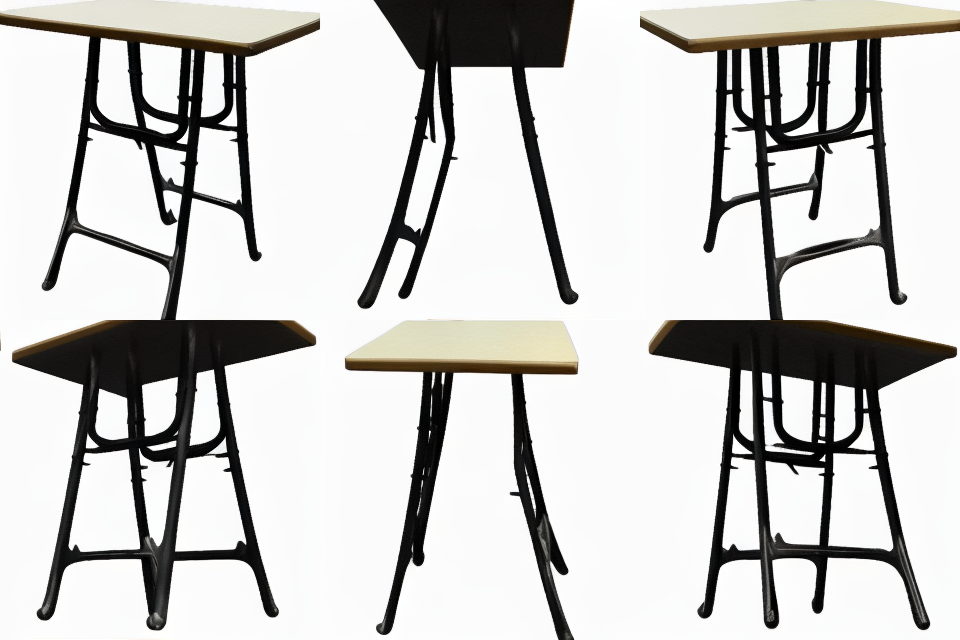

You can find the generated multi-view image at: /tmp/gradio/057916b8214aa0e4cae34115b0b024ea54e5abb535cbcf90377482036679a04c/image.png


In [16]:
from gradio_client import Client, handle_file # Changed 'file' to 'handle_file'
from PIL import Image
import requests
from io import BytesIO

# Re-initialize client if necessary and re-run the preprocessing step to ensure 'result' is defined
client = Client("SIGMitch/InstantMesh")
input_image_url = '/content/photo_14_2024-08-20_11-55-42-removebg-preview.png'

try:
    # Attempt to use existing 'result' if available, otherwise re-run preprocess
    _ = result # Check if 'result' is defined
    print("Using existing 'result' from previous preprocess step.")
except NameError:
    print(" 'result' not found. Re-running /preprocess step...")
    result = client.predict(
        input_image=handle_file(input_image_url), # Changed 'file' to 'handle_file'
        do_remove_background=True,
        api_name="/preprocess"
    )
    print(f"Re-processed image output file path: {result}")

# Re-run the multi-view generation step to ensure 'mvs_result' is defined
input_image_for_mvs = result

try:
    _ = mvs_result # Check if 'mvs_result' is defined
    print("Using existing 'mvs_result' from previous generate_mvs step.")
except NameError:
    print("'mvs_result' not found. Re-running /generate_mvs step...")
    mvs_result = client.predict(
        input_image=handle_file(input_image_for_mvs), # Changed 'file' to 'handle_file'
        sample_steps=75,
        sample_seed=42,
        api_name="/generate_mvs"
    )
    print(f"Re-generated multi-views output file path: {mvs_result}")

# Now, display the mvs_result image
img_path = mvs_result
img = Image.open(img_path)
display(img)
print(f"You can find the generated multi-view image at: {img_path}")

# To download this image, you can right-click on the displayed image and select "Save Image As...".
# For programmatic saving, you would typically use img.save('filename.png').